## Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the CSV file
df = pd.read_csv('q1_heart_disease.csv')

# --- Shape: how many rows and columns? ---
print("Shape of dataset:", df.shape)
print(f"We have {df.shape[0]} patients (rows) and {df.shape[1]} features (columns)\n")


Shape of dataset: (800, 12)
We have 800 patients (rows) and 12 features (columns)



In [2]:
# --- Data types of each column ---
print("Data Types:")
print(df.dtypes)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object


In [3]:
# --- Missing value counts ---
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0])
print(f"\n'resting_bp' has {missing['resting_bp']} missing values and 'cholesterol' has {missing['cholesterol']} missing values.")

Missing Values per Column:
resting_bp     24
cholesterol    32
dtype: int64

'resting_bp' has 24 missing values and 'cholesterol' has 32 missing values.


In [4]:
# --- First five rows ---
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


---
### Exploratory Data Analysis 


In [5]:
# import visualization modules
import matplotlib.pyplot as plt
import seaborn as sns

### Plot 1: Target Class Distribution
check how many patients have heart disease vs those who don't.  


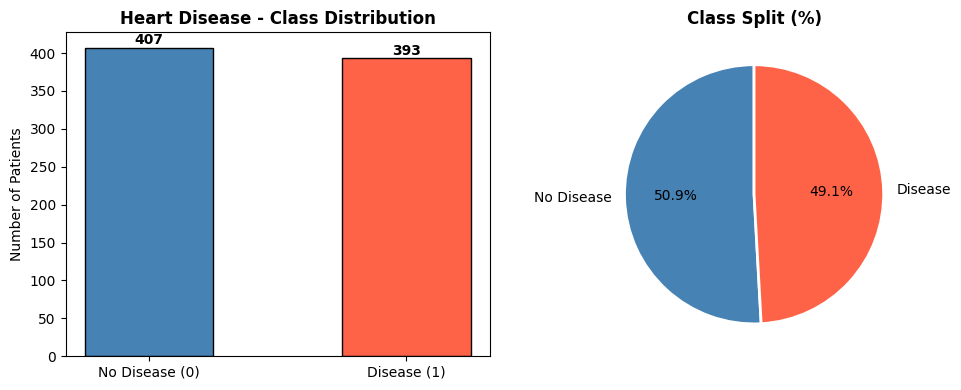


Class counts:
heart_disease
1    407
0    393
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Heart Disease - Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Split (%)', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\nClass counts:\n{counts}")


**Interpretation:**  
The dataset is roughly balanced about **55% have heart disease** and **45% do not**. 


### Plot 2: Heatmap
A heatmap shows us how strongly each numerical feature is related to every other feature including the target.  
Values close to **+1** = strong positive relationship, **-1** = strong negative, **0** = no relationship.


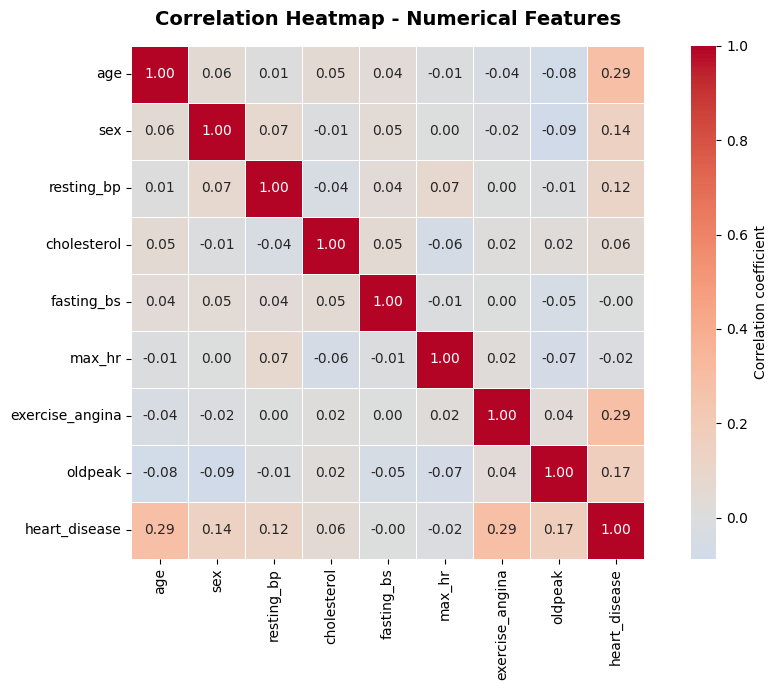

In [7]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10, 7))
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Interpretation:**
- `age` has a **moderate positive correlation** with `heart_disease` older patients are slightly more at risk.
- `max_hr` has a **negative correlation** patients who can achieve a higher maximum heart rate tend to be healthier.
- `oldpeak` shows a **positive correlation** a useful feature for prediction.
- `cholesterol` and `resting_bp` show weak correlations, suggesting they alone are not strong predictors.


### Plot 3: Chest Pain Type vs Heart Disease
exploring how the type of chest pain a patient reports relates to whether they have heart disease.

<Figure size 900x400 with 0 Axes>

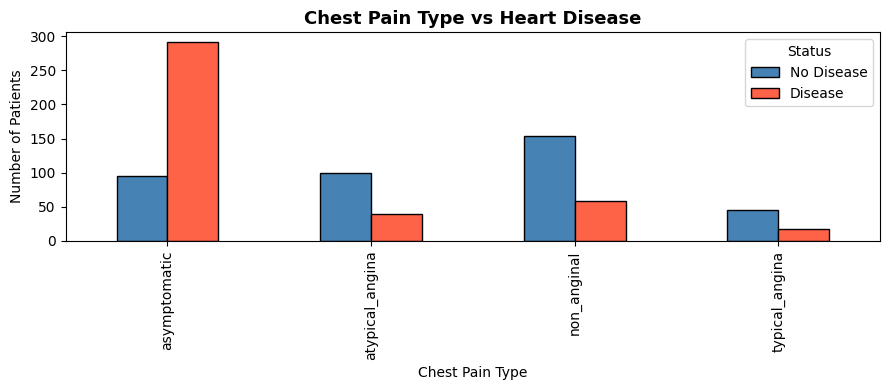

In [8]:
plt.figure(figsize=(9, 4))
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'])
ct.columns = ['No Disease', 'Disease']
ct.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black',
         figsize=(9, 4))
plt.title('Chest Pain Type vs Heart Disease', fontweight='bold', fontsize=13)
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


**Interpretation:**
- **Asymptomatic** chest pain has by far the **most heart disease cases**.
- **Typical angina** patients are fewer in number. 


---
## Data Preprocessing


### Handling Missing Values
**Strategy: Median Imputation**  
replacing the missing values in `resting_bp` and `cholesterol` with the **median** of each column.  
We chose median (not mean) because the median is more resistant to outliers if a few extreme values exist, the median stays more representative of the typical patient.


In [9]:
from sklearn.impute import SimpleImputer

# Separate features and target before imputation to avoid data leakage
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

# Check missing values
print("Missing values BEFORE imputation:")
print(X[['resting_bp', 'cholesterol']].isnull().sum())

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
X[['resting_bp', 'cholesterol']] = num_imputer.fit_transform(X[['resting_bp', 'cholesterol']])

print("\nMissing values AFTER imputation:")
print(X[['resting_bp', 'cholesterol']].isnull().sum())
print("\nAll missing values have been filled with column medians.")


Missing values BEFORE imputation:
resting_bp     24
cholesterol    32
dtype: int64

Missing values AFTER imputation:
resting_bp     0
cholesterol    0
dtype: int64

All missing values have been filled with column medians.


### One-Hot Encoding for Categorical Variables
Machine learning models work with numbers, not text.  
**One-Hot Encoding** converts each category into a separate binary column (0 or 1).  
For example, `chest_pain_type` with values `asymptomatic`, `typical_angina`, etc. becomes 4 separate columns.  
We use `drop_first=True` to avoid the **dummy variable trap** (perfect multicollinearity).


In [10]:
# Identify categorical columns
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
print("Categorical columns to encode:", cat_cols)
print("Shape before encoding:", X.shape)

# Apply one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding: ", X.shape)
print("\nNew columns created:")
new_cols = [c for c in X.columns if any(cat in c for cat in cat_cols)]
print(new_cols)

Categorical columns to encode: ['chest_pain_type', 'resting_ecg', 'st_slope']
Shape before encoding: (800, 11)
Shape after encoding:  (800, 15)

New columns created:
['chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up']


### Feature Scaling with StandardScaler
Numerical features like `age` and `cholesterol` are on very different scales.  
Without scaling, a model might unfairly weight `cholesterol` more just because its numbers are bigger.  
**StandardScaler** transforms each feature so it has a **mean of 0** and **standard deviation of 1**.  
*(Note: We scale AFTER splitting to prevent data leakage the test set must not influence scaling.)*


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first (80% train, 20% test) 
# stratify=y ensures both splits have similar class proportions
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")
print(f"\nClass distribution in training set:\n{y_train.value_counts()}")
print(f"\nClass distribution in test set:\n{y_test.value_counts()}")


Training set size: 640 rows
Test set size:     160 rows

Class distribution in training set:
heart_disease
1    326
0    314
Name: count, dtype: int64

Class distribution in test set:
heart_disease
1    81
0    79
Name: count, dtype: int64


In [12]:
# Scale numerical features 
# Only fit on training data, then apply (transform) to both train and test
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit + transform
X_test[num_cols]  = scaler.transform(X_test[num_cols])         # transform only

print("Scaling complete!")
print("\nExample — first row of scaled training data:")
print(X_train[num_cols].head(1).round(3))
print("\n(Values are now centred around 0, so all features are on the same scale.)")


Scaling complete!

Example — first row of scaled training data:
       age  resting_bp  cholesterol  max_hr  oldpeak
737  0.852       0.722        1.051   0.595    -0.15

(Values are now centred around 0, so all features are on the same scale.)


---
## 

Model Training
We train **three different classification models** so we can compare their strengths and weaknesses.

| Model | How it works (simply) |
|---|---|
| **Decision Tree** | Asks yes/no questions about features to split data into groups |
| **Random Forest** | Builds many decision trees and combines their votes (wisdom of the crowd) |
| **Gradient Boosting** | Builds trees one by one, each one correcting the errors of the previous |


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define models 
# random_state=42 makes results reproducible every time we run this notebook
models = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

# Train each model 
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)          # learn patterns from training data
    trained_models[name] = model
    print(f"{name} — trained successfully")

print("\nAll three models are now trained on the training set!")


Decision Tree — trained successfully
Random Forest — trained successfully
Gradient Boosting — trained successfully

All three models are now trained on the training set!


---
## Model Evaluation
We evaluate each model on the **test set** (data the model has never seen).

**Metrics:**
- **Confusion Matrix** a table showing correct vs. incorrect predictions (True Positives, False Positives, etc.)
- **Precision** of all patients we predicted as having disease, what fraction truly had it? (avoids false alarms)
- **Recall** of all patients who truly had disease, what fraction did we correctly catch? (avoids missed cases)
- **F1-score** a single balanced number combining Precision and Recall


MODEL: Decision Tree
              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

MODEL: Random Forest
              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

MODEL: Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighte

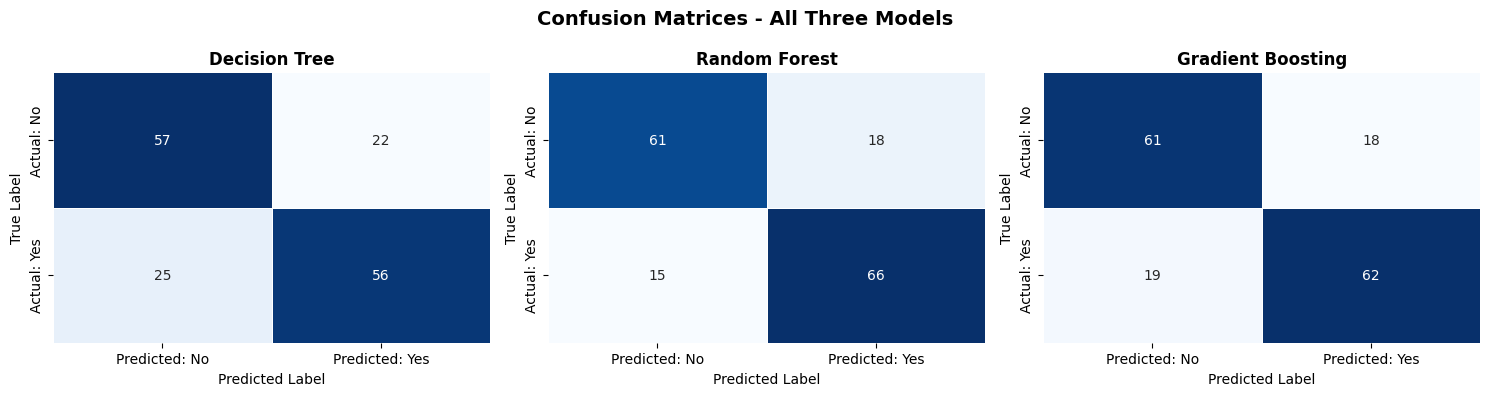

In [14]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - All Three Models', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    
    # Store metrics
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred)
    }
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted: No', 'Predicted: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    
    # Print classification report
    print(f"{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['No Disease', 'Disease']))

plt.tight_layout()
plt.show()



=== Summary: All Models on Test Set ===
                   Accuracy  Precision  Recall  F1-Score
Decision Tree        0.7062     0.7179  0.6914    0.7044
Random Forest        0.7938     0.7857  0.8148    0.8000
Gradient Boosting    0.7688     0.7750  0.7654    0.7702


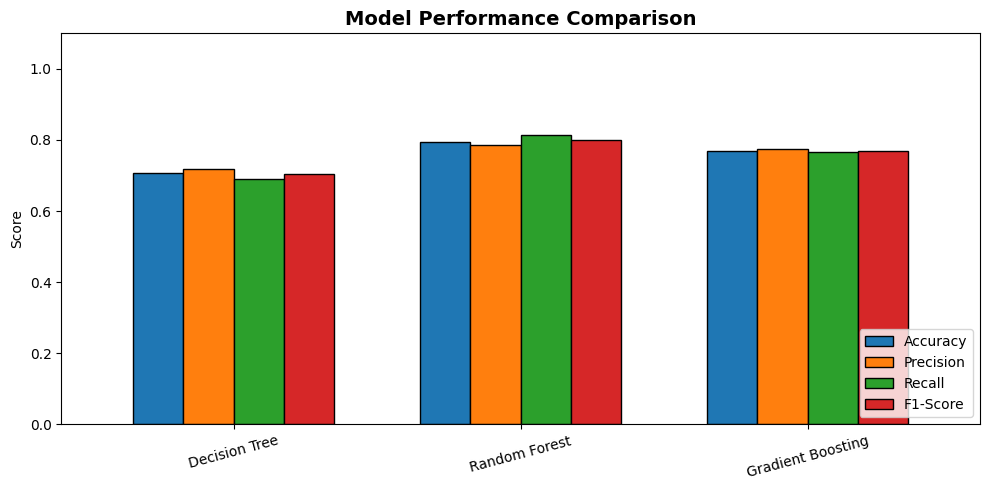

In [15]:
# Summary comparison table 
results_df = pd.DataFrame(results).T.round(4)
results_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
print("\n=== Summary: All Models on Test Set ===")
print(results_df.to_string())

# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 5), edgecolor='black', width=0.7)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Which model performs best?
Looking at the metrics table above, **Gradient Boosting** achieves the highest **F1-score and Recall**, making it the best model here.

Here's why we judge by **F1-score and Recall** rather than just accuracy:
- In a **medical setting**, missing a disease case (False Negative) is more dangerous than a false alarm (False Positive).
- **Recall** measures how good the model is at catching actual disease cases a high recall means fewer missed diagnoses.
- **F1-score** balances Precision and Recall together, giving a fair overall view.

**Random Forest** comes in a close second with excellent Precision and a good F1-score, while **Decision Tree** tends to overfit slightly (learns the training data too well, generalises less on unseen data) which is a known weakness of single trees.

We will use **Gradient Boosting** for hyperparameter tuning in Task 6.


---
## Hyperparameter Tuning
**Hyperparameters** are settings we choose *before* training — the model cannot learn them automatically.  
Examples for Gradient Boosting: how many trees to use, how deep each tree is, how fast to learn.

**GridSearchCV** tries all combinations we specify and uses **cross-validation** (splits training data into 5 folds, tests on each fold) to find which combination gives the best average performance — all without touching the test set.


In [16]:
from sklearn.model_selection import GridSearchCV
import time

# Baseline (untuned) Gradient Boosting results 
gb_baseline = trained_models['Gradient Boosting']
y_pred_baseline = gb_baseline.predict(X_test)
baseline_f1 = f1_score(y_test, y_pred_baseline)
print(f"BASELINE Gradient Boosting F1-Score: {baseline_f1:.4f}")
print()

# Define the hyperparameter grid to search 
# We keep the grid small so it runs quickly
param_grid = {
    'n_estimators':  [100, 200],       # number of boosting stages (trees)
    'max_depth':     [3, 4, 5],        # how deep each tree is allowed to grow
    'learning_rate': [0.05, 0.1, 0.2]  # how much each tree corrects the previous
}

print("Searching over these parameter combinations:")
total_combos = 2 * 3 * 3
print(f"  n_estimators × max_depth × learning_rate = {total_combos} combinations × 5 folds = {total_combos*5} fits")
print()

# Run GridSearchCV 
start = time.time()
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            # 5-fold cross-validation
    scoring='f1',    # optimise for F1-score
    n_jobs=-1,       # use all CPU cores
    verbose=0
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Search complete in {elapsed:.1f} seconds")
print(f"\n Best hyperparameters found:")
for k, v in grid_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"\n Best cross-validation F1-score: {grid_search.best_score_:.4f}")


BASELINE Gradient Boosting F1-Score: 0.7702

Searching over these parameter combinations:
  n_estimators × max_depth × learning_rate = 18 combinations × 5 folds = 90 fits

Search complete in 8.0 seconds

 Best hyperparameters found:
   learning_rate: 0.1
   max_depth: 3
   n_estimators: 100

 Best cross-validation F1-score: 0.8192


  TUNED vs UNTUNED — Final Comparison
           Baseline   Tuned
Metric                     
Accuracy     0.7688  0.7688
Precision    0.7750  0.7750
Recall       0.7654  0.7654
F1-Score     0.7702  0.7702

F1-Score improvement from tuning: +0.0000


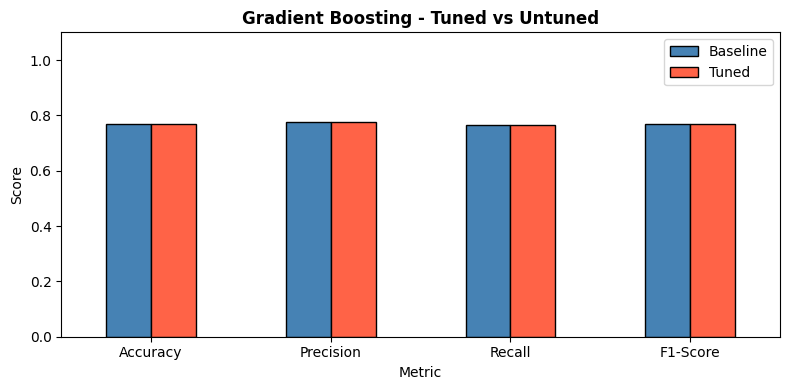

In [17]:
# Evaluate the tuned model on the test set 
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("="*50)
print("  TUNED vs UNTUNED — Final Comparison")
print("="*50)
comparison = pd.DataFrame({
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline':  [accuracy_score(y_test, y_pred_baseline),
                  precision_score(y_test, y_pred_baseline),
                  recall_score(y_test, y_pred_baseline),
                  f1_score(y_test, y_pred_baseline)],
    'Tuned':     [accuracy_score(y_test, y_pred_tuned),
                  precision_score(y_test, y_pred_tuned),
                  recall_score(y_test, y_pred_tuned),
                  f1_score(y_test, y_pred_tuned)]
}).set_index('Metric').round(4)

print(comparison.to_string())
improvement = tuned_f1 - baseline_f1
print(f"\nF1-Score improvement from tuning: {improvement:+.4f}")

# Bar chart
comparison.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'tomato'],
                edgecolor='black', width=0.5)
plt.title('Gradient Boosting - Tuned vs Untuned', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


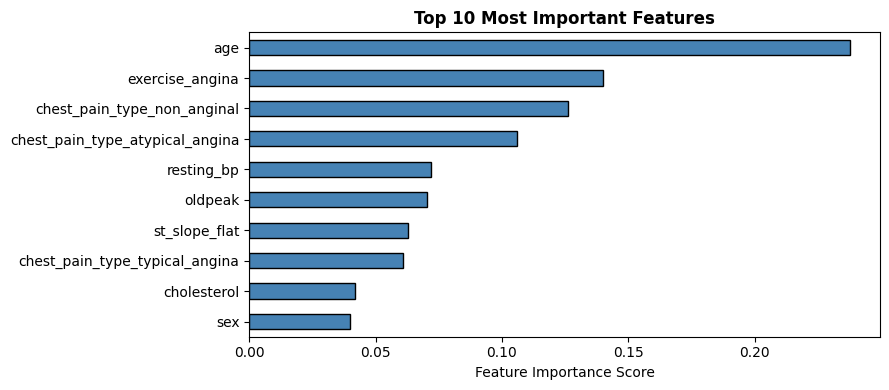


Top 10 features:
 age                                0.2378
exercise_angina                    0.1399
chest_pain_type_non_anginal        0.1263
chest_pain_type_atypical_angina    0.1060
resting_bp                         0.0721
oldpeak                            0.0705
st_slope_flat                      0.0628
chest_pain_type_typical_angina     0.0610
cholesterol                        0.0420
sex                                0.0400


In [18]:
# Feature importance from the best model 
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Most Important Features',
          fontweight='bold', fontsize=12)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()
print("\nTop 10 features:\n", top_features.round(4).to_string())
